# 1. Signal Extraction

#### Dataset
For this tutorial, we use a FIB-SEM dataset from the LimeSeg paper (https://zenodo.org/records/1472859). The plasma membrane at a budding site was extracted (`data/lime_pm_2.tif`), which is used as the input for the entire workflow.

In [2]:
import sys
import os
import numpy as np
from pathlib import Path

#### Add program source to sys.path ####
project_root = Path().resolve()
sys.path.append(str(project_root / "../../src"))

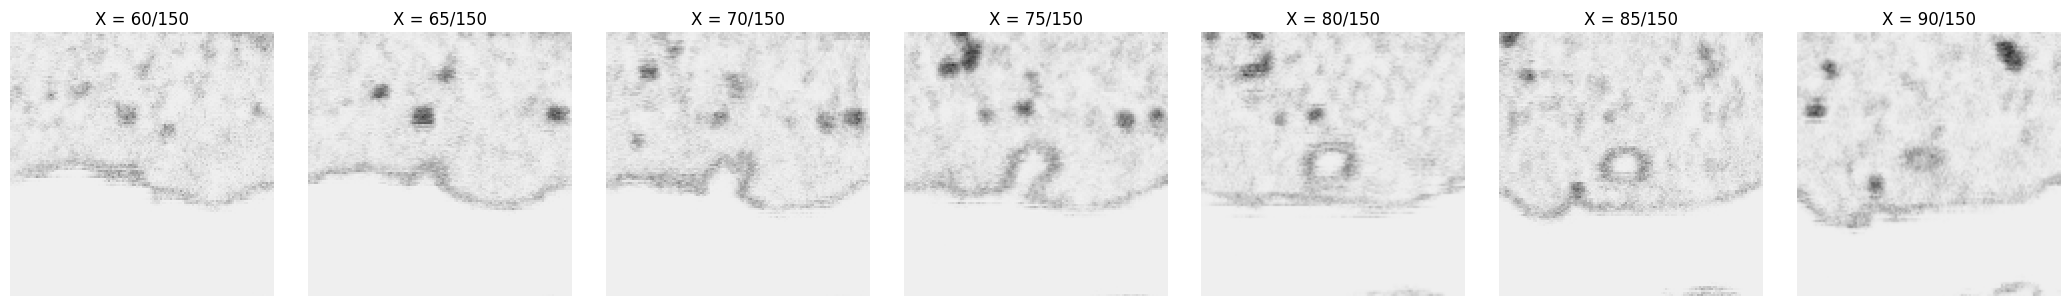

In [3]:
import tifffile as tiff
from data_generation.mesh_to_cryoet import plot_multiple_slices

#### Import tiff file ####
my_data_path = "../dat"
shape = "lime_pm_2"
file_name = f"{shape}.tif"
file_path = os.path.join(my_data_path, file_name)
cryoet = tiff.imread(file_path)
cryoet = cryoet / cryoet.max()
cryoet = 1 - cryoet

#### Visualize data ####
slices = list(range(60, 95, 5))
visualize = cryoet
plot_multiple_slices(visualize, axis='x', slices=slices)

#### Extract edge/bulk signal
In this tutorial, we extract edge and bulk signals using a simple thresholding method. We enhance the contrast between membrane and non-membrane regions, then sample edge points above the threshold and bulk points below it. For practical applications, this step can also be performed using semantic segmentation methods (e.g., MemBrain-seg). Sampled edge/bulk points are stored in `../dat/pt_e_lime_pm_2.npz`.

Downsampled shape: (132, 132, 132)
Padded shape:     (132, 132, 132)
Resized shape:    (64, 64, 64)
Normalized shape: (64, 64, 64)


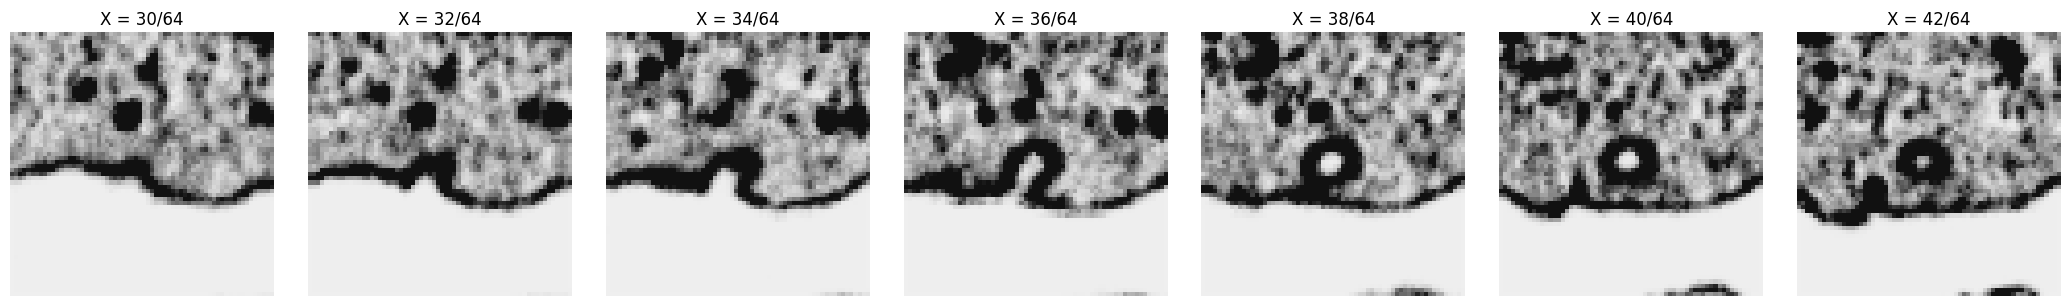

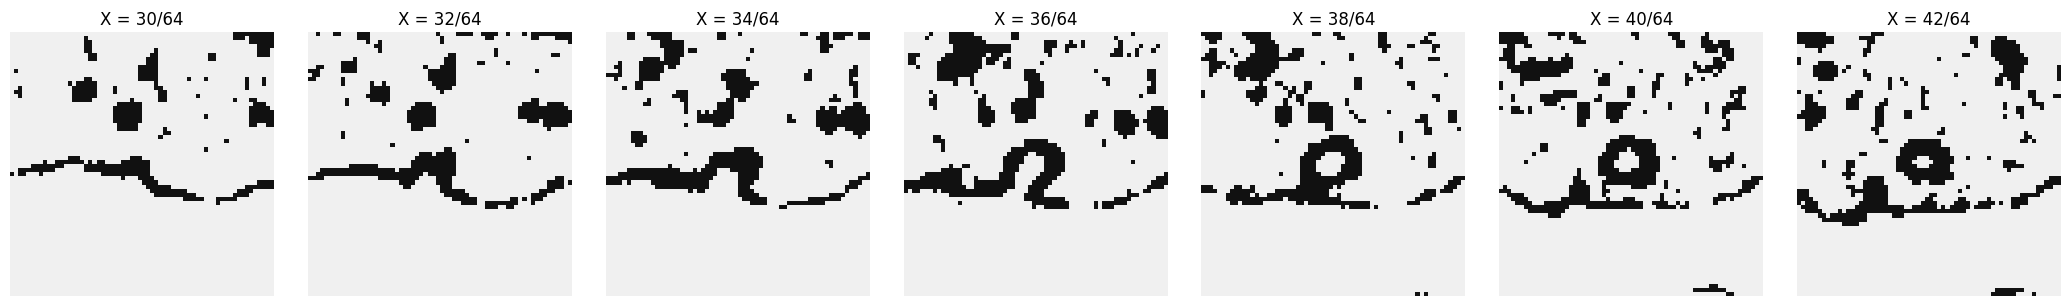

In [4]:
from data_generation.preprocess import downsample

#### Downsample and normalize image ####
z_min = 0; z_max = cryoet.shape[1]
y_min = 0; y_max = cryoet.shape[1]
x_min = 0; x_max = cryoet.shape[2]
GRID_SIZE = 64
intensity_max = 6
k_xy = 1
normalized = downsample(cryoet, x_min, x_max, y_min, y_max, z_min, z_max, GRID_SIZE=GRID_SIZE, intensity_max=6)

#### Visualize data ####
slices = list(range(30, 44, 2))
visualize = normalized
plot_multiple_slices(visualize, axis='x', slices=slices) 
plot_multiple_slices(visualize, axis='x', slices=slices, thre=0.8) # thresholded at intensity = 0.8

#### Save downsampled tiff ####
tiff.imwrite(f"../dat/downsampled_{shape}.tif", normalized)

edge size:  32263.0
bulk size:  52429.0


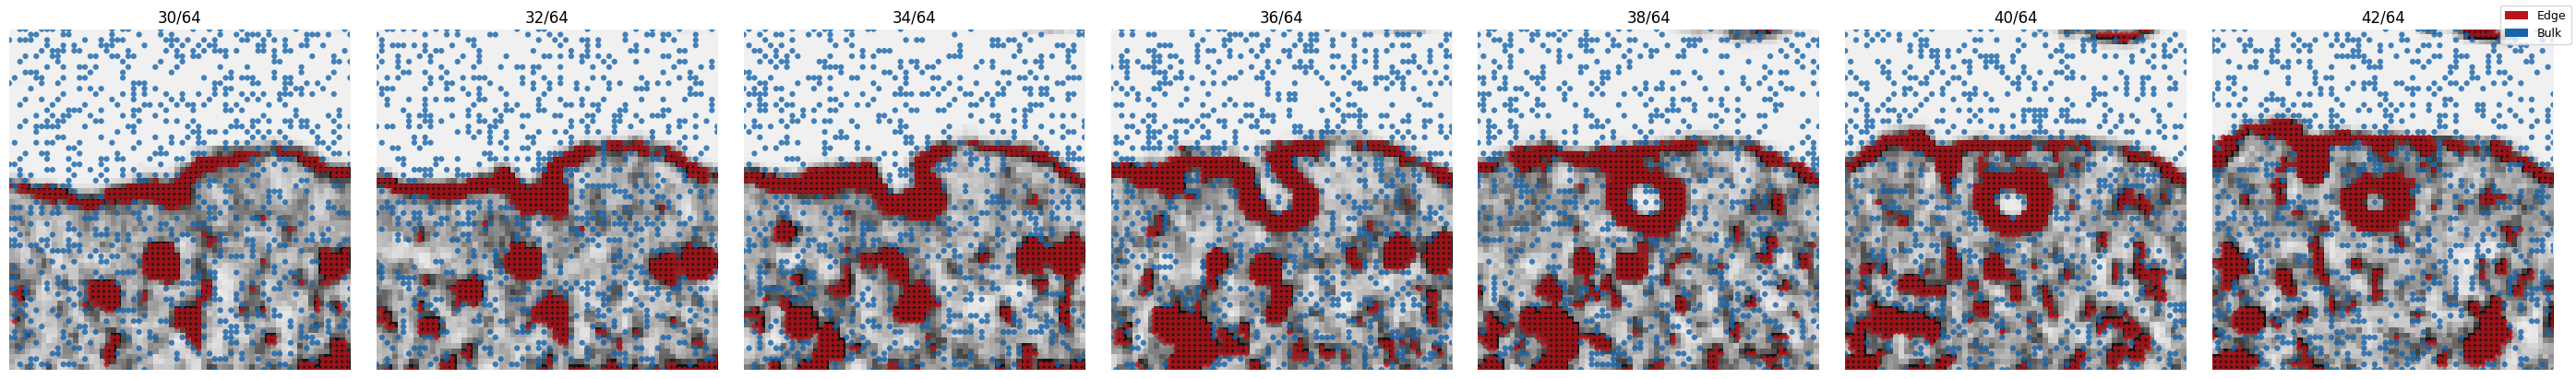

In [14]:
from data_generation.preprocess import downsample_binary_mask_to_fraction, overlay_points_on_cryoet, build_data_edge_from_masks
from pinn.utils import save_pts_data

#### Sample edge/bulk signals ####
threshold = 0.8
target_edge = 1.0
target_bulk = 0.2

edge = (normalized > threshold)
bulk = (~edge)
edge = downsample_binary_mask_to_fraction(edge, target_frac=target_edge, seed=0)
bulk = downsample_binary_mask_to_fraction(bulk, target_frac=target_bulk, seed=0)
edge = edge.astype(np.float32)
bulk = bulk.astype(np.float32)
print("edge size: ", edge.sum())
print("bulk size: ", bulk.sum())

#### Save point data ####
data_edge = build_data_edge_from_masks(edge=edge, bulk=bulk, volume_shape=normalized.shape)
meta_data ={
    "type": "edge",
    "label_meaning": {1: "edge", 0: "bulk"},
    "GRID_SIZE": GRID_SIZE,
    "edge_min": threshold,
    "target_edge": target_edge,
    "target_bulk": target_bulk,
    "shape": shape,
}
save_pts_data(data_edge, f"../dat/pt_e_{shape}.npz", meta_data)

#### Visualize data ####
slices = list(range(30, 44, 2))
data = load_pts_data(f"../dat/pt_e_{shape}.npz", perm=(2,1,0))
edge = data["points"][data["label"] == 1]
bulk = data["points"][data["label"] == 0]
overlays = [
    {"data": edge, "label": "Edge", "cmap": "Reds"},
    {"data": bulk, "label": "Bulk", "cmap": "Blues"},
]
overlay_points_on_cryoet(cryoet=normalized, overlays=overlays, axis='x', slice_indices=slices, alpha=0.8)


#### Extract inside/outside signal
In this tutorial, we manually extract the inside and outside signals. In practice, this step can also be performed using semantic segmentation methods or by leveraging intensity differences between regions. The extracted point data are stored in `dat/pt_s_lime_pm_2.npz`.

In [5]:
from data_generation.preprocess import napari_sign_labeler

#### Manually sample points and save data ####
## It should be done at local machine since it uses graphic user interface 
# %gui qt
# save_path = f"../dat/pt_s_{shape}.npz"
# viewer, pts_plus, pts_minus = napari_sign_labeler(normalized, save_path=save_path, size=5)

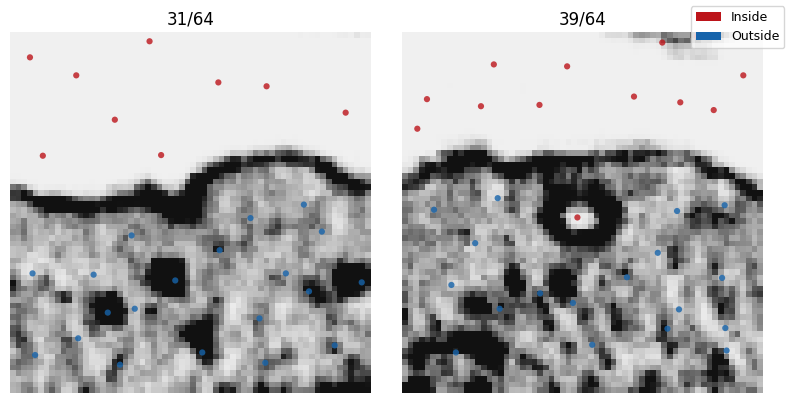

In [9]:
from pinn.utils import load_pts_data
from data_generation.preprocess import overlay_points_on_cryoet

#### Visualize data ####
sign = load_pts_data(f"../dat/pt_s_{shape}.npz", perm=(2,1,0))
inside  = sign["points"][sign["label"] == 1]
outside = sign["points"][sign["label"] == -1]
overlays = [
    {"data": inside,  "label": "Inside",  "cmap": "Reds"},
    {"data": outside, "label": "Outside", "cmap": "Blues"},
]
slices=[31, 39]
overlay_points_on_cryoet(cryoet=normalized, overlays=overlays, axis='x', slice_indices=slices, alpha=0.8)

#### Extract collocatioin points ####
Collocation points are used to evaluate the physics loss. We sample these points randomly within the simulation box. Sampled collocation points are stored in `../dat/pt_p_lime_pm_2.npz`.

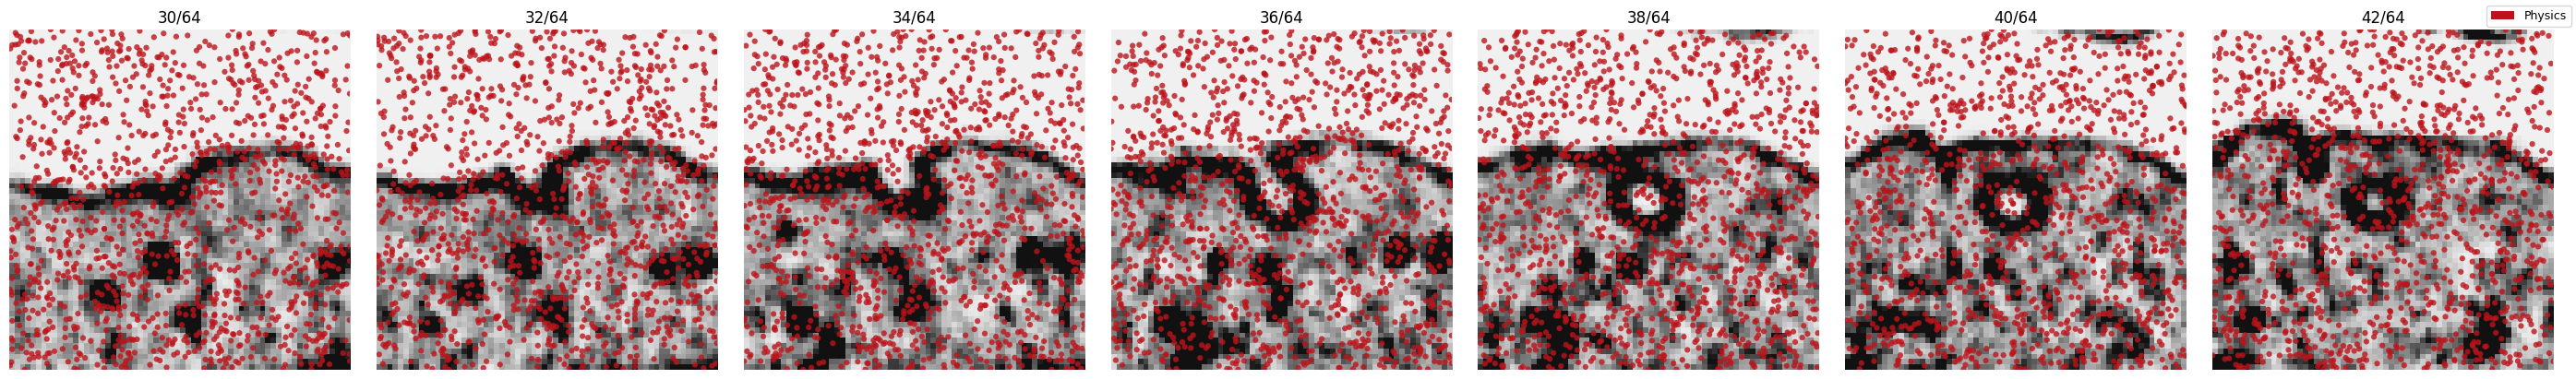

In [22]:
import jax

#### Randomly sample collocation points ####
seed = 0
key = jax.random.PRNGKey(seed)
num_collocation = 80000
x_train = (jax.random.uniform(key, (num_collocation, 3), minval=-1, maxval=1))
data_phys = {"points": x_train}
meta_phys = {
    "type": "phys",
    "n_sample": num_collocation,
    "seed": seed,
    "sampling": "random",
}

#### Save data ####
save_pts_data(data_phys, f"../dat/pt_p_{shape}.npz", meta_phys)

#### Visualize data ####
slices = list(range(30, 44, 2))
data = load_pts_data(f"../dat/pt_p_{shape}.npz", perm=(2,1,0))
phys = data["points"]
overlays = [
    {"data": phys, "label": "Physics", "cmap": "Reds"},
]
overlay_points_on_cryoet(cryoet=normalized, overlays=overlays, axis='x', slice_indices=slices, alpha=0.8)

In [8]:
import importlib
import data_generation.preprocess as preprocess
importlib.reload(preprocess)

<module 'data_generation.preprocess' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/tutorial/note/../../src/data_generation/preprocess.py'>